In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import glob #for path/to/folder
from collections import Counter

#for extracting hand landmarks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

### What we know about the dataset
[Link to the old Kaggle Set](https://www.kaggle.com/datasets/ayuraj/asl-dataset)
* A bunch of images of A-Z and 0-9 in ASL (we'll be focusing on A-Z except J and Z since they require more hand motions); 400x400 cropped jpeg images
* each character has many versions/images of the sign, with slight variations in each of the hand positions to account for different lighting
* as mentioned in the kaggle set's description, this is mainly tailored to CNNs, but we should be able to use this with other models (like Linear SVMs)

 (the above is an older dataset we were working with - however there were issues with the implementation of the model in the webcam setup as well as the quality of the dataset (number of images per letter + hand landmark detection issues), so we opted to go for the dataset mentioned below)

 [Link to the new Kaggle Set](https://www.kaggle.com/datasets/kapillondhe/american-sign-language)
 * Bunch of regular hand images from A-Z and 0-9 in ASL 
 * hands are in slightly different angles and parts of the screen

In [ ]:
#reading data from asl dataset:
#img_dir = 'asl_dataset'
#sub_dirs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y'] #only looking at these characters 
img_dir = 'ASLDataset/Train'
sub_dirs = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

sub_dirs_count, indx = [], 0
data = [] 
for dir in sub_dirs:
    path = f'{img_dir}/{dir}'
    #print(path)
    data_path = os.path.join(f'{img_dir}/{dir}',"*.jpg")
    files = glob.glob(data_path) 
    count_files = 0 #just to help find all the images of each letter in dataset
    files_letter = 0 #make sure to get 200 of each dataset
    for f1 in files: 
        img = cv2.imread(f1) 
        #make sure img is read and exists
        if img is None:
            print("failed to load ", f1)
            
        #change bgr to rgb
        RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        data.append(RGB_img) 
        count_files += 1
        files_letter += 1
        if files_letter == 200: 
            break #dont do too much of the dataset
    sub_dirs_count.append((sub_dirs[indx], count_files))
    indx+=1
#print(len(data))
print("successfully read all images")
# just to make sure image is stored properly
#plt.imshow(data[0])
#plt.waitforbuttonpress()
#plt.close('all')

successfully read all images


# of Images in dataset: 5000


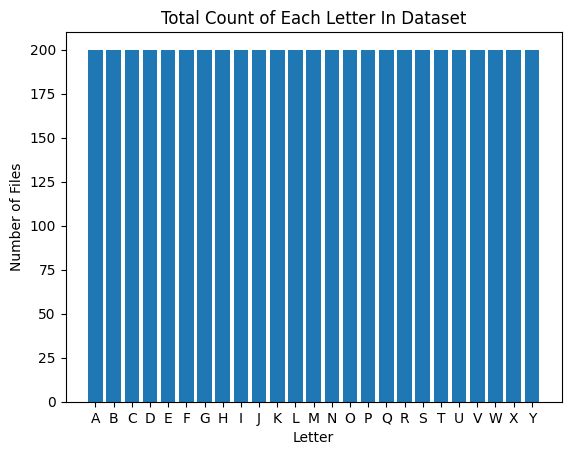

In [5]:
#information of all the images:
print("# of Images in dataset:", len(data))
#print(sub_dirs_count)
plt.bar(*zip(*sub_dirs_count))
plt.title("Total Count of Each Letter In Dataset")
plt.xlabel("Letter")
plt.ylabel("Number of Files")
plt.show()

We extracted 200 out of the 5000+ images the dataset has since our devices take too long to read the images and extract the landmarks from each of the images.

### Preprocessing Data
Using the cropped hand images, grab hand landmark data using Google's Mediapipe library

In [ ]:
#installing mediapipe - note that Python version 3.13+ doesn't support mediapipe for some reason
#!pip install -q mediapipe

#using a model that is ready-made to extract hand points from an image
#for windows: 
#!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task 

#for mac:
!curl -O https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

#getting the drawing utils
mp_drawing = mp.solutions.drawing_utils

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7635k  100 7635k    0     0  5448k      0  0:00:01  0:00:01 --:--:-- 5450k


In [6]:
#setting up the hand landmark detection model:
base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task', 
    delegate=python.BaseOptions.Delegate.CPU
    )
options = vision.HandLandmarkerOptions(
    base_options=base_options, 
    running_mode=vision.RunningMode.IMAGE, 
    num_hands=1, #dataset only shows 1 hand for each sign
    min_hand_detection_confidence=0.1,
    min_tracking_confidence=0.2
    )
detector = vision.HandLandmarker.create_from_options(options=options)


I0000 00:00:1777928893.228290 29553219 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777928893.287953 29566216 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777928893.341947 29566216 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [19]:
#getting hand landmarks from one image:
#test = cv2.imread('asl_dataset/a/hand1_a_bot_seg_4_cropped.jpeg')
#test = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

#test = cv2.resize(data[0], (640, 480))

test = np.ascontiguousarray(data[0])
image = mp.Image(
    image_format=mp.ImageFormat.SRGB, 
    data=test
    )

result = detector.detect(image)

In [25]:
print("hands detected = ", len(result.hand_landmarks))
print(result.hand_landmarks)

hands detected =  1
[[NormalizedLandmark(x=0.3589232861995697, y=0.7865810394287109, z=-1.0897668971665553e-06, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.2301635891199112, y=0.7333558201789856, z=-0.046342287212610245, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.12683407962322235, y=0.6155452728271484, z=-0.06384692341089249, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.0944945365190506, y=0.49180418252944946, z=-0.08320382982492447, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.11378807574510574, y=0.40342241525650024, z=-0.08674401044845581, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.18671131134033203, y=0.47035637497901917, z=0.01607629470527172, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.16764973104000092, y=0.37712767720222473, z=-0.04431658983230591, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.17707009613513947, y=0.48398077487945557, z=-0.07104925811290741, visibility=0.0, presence=0.0), NormalizedLandmark(x=

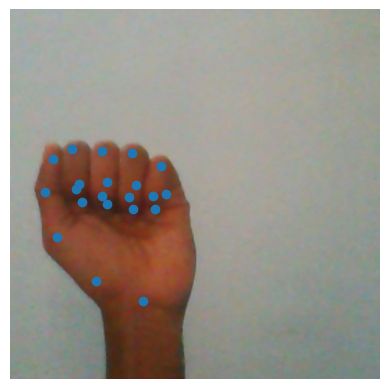

In [21]:
def plot_points(rgb_img, detection_result):
    h, w, _ = rgb_img.shape

    plt.imshow(rgb_img)

    for hand_landmarks in detection_result.hand_landmarks:
        #scaling back to the image's dimensions
        xs = [lm.x * w for lm in hand_landmarks]
        ys = [lm.y * h for lm in hand_landmarks]

        plt.scatter(xs, ys)

    plt.axis('off')
    plt.show()

plot_points(test, detection_result=result)

Above code was just to make sure we are properly getting hand landmarks from the images. Notice how we had to scale the image before running it through the detector. We are not sure why this happens, but it could be due to the nature of the image itself being too hard for the detection model to get landmarks. 

However, trying this with [Google's Mediapipe Hand Detection Demo](https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/hand_landmarker/python/hand_landmarker.ipynb) proved this wrong. Will need to fix this.

In [ ]:
#storing dataset and labels:
hand_landmark_data = []
hand_landmark_label = []

#directories of dataset
#img_dir = 'asl_dataset'
#sub_dirs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y'] #only looking at these characters 
img_dir = 'ASLDataset/Train'
sub_dirs = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

for dir in sub_dirs:
    path = f'{img_dir}/{dir}'
    #print(path)
    data_path = os.path.join(f'{img_dir}/{dir}',"*.jpg")
    files = glob.glob(data_path) 
    count_files = 0 #just to help find all the images of each letter in dataset
    for f1 in files: 
        img = cv2.imread(f1) 
        count_files += 1
        #make sure img is read and exists
        if img is None:
            print("failed to load ", f1)
            continue
            
        #change bgr to rgb
        RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        #turn into mediapipe image before extracting landmarks (if possible)
        #test = cv2.resize(RGB_img, (640, 480))
        test = np.ascontiguousarray(test)
        image = mp.Image(
            image_format=mp.ImageFormat.SRGB, 
            data=test
        )
        result = detector.detect(image) #gets all hand landmarks 
                                        #in the image for each hand detected
        if not result.hand_landmarks:
            continue
        else:
            hand = result.hand_landmarks[0]
            coords = []
            for landmark in hand:
                coords.extend([landmark.x, landmark.y, landmark.z])
            hand_landmark_data.append(coords)
            hand_landmark_label.append(dir)
        if count_files == 200: break


### Analysis of Data

Due to limitations within Mediapipe's hand detection, there are certain requirements that must be met - images might not have their hand landmarks marked since they might not show a full wrist, which is used to detect the palm as an origin point and then detects the other joints of the hand. This dataset does not have this problem since none of these hands are heavily cropped.

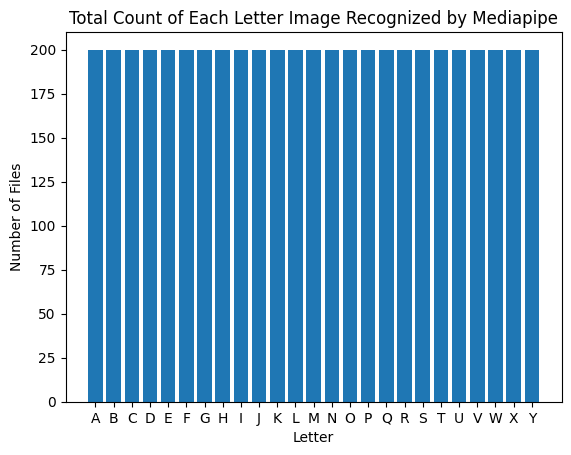

Counter({'A': 200, 'B': 200, 'C': 200, 'D': 200, 'E': 200, 'F': 200, 'G': 200, 'H': 200, 'I': 200, 'J': 200, 'K': 200, 'L': 200, 'M': 200, 'N': 200, 'O': 200, 'P': 200, 'Q': 200, 'R': 200, 'S': 200, 'T': 200, 'U': 200, 'V': 200, 'W': 200, 'X': 200, 'Y': 200})
Number of letters recoginzed by Mediapipe: 5000
Total images recognzied by Mediapipe: 100.00%


In [15]:
#get count of all hand images that were detected by the hand_landmarks.task model
label_counts = Counter(hand_landmark_label)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("Total Count of Each Letter Image Recognized by Mediapipe")
plt.xlabel("Letter")
plt.ylabel("Number of Files")
plt.show()

print(label_counts)
print("Number of letters recoginzed by Mediapipe:", len(hand_landmark_data))

print("Total images recognzied by Mediapipe:", f"{len(hand_landmark_data)/len(data)*100:.2f}%")

This dataset's images can all have hand landmarks detected by it.

In [28]:
print(hand_landmark_data[0])
print(max(hand_landmark_data[0]))
print(min(hand_landmark_data[0]))


[0.1234603002667427, 0.7074409127235413, 1.2511391105363145e-06, 0.19452306628227234, 0.7520253658294678, -0.08271283656358719, 0.31603899598121643, 0.7586692571640015, -0.11463503539562225, 0.426501989364624, 0.7774073481559753, -0.12942510843276978, 0.5148095488548279, 0.7923028469085693, -0.14200063049793243, 0.34462738037109375, 0.5539961457252502, -0.10761183500289917, 0.4703870713710785, 0.5146185159683228, -0.16076666116714478, 0.5749087333679199, 0.529358446598053, -0.19939836859703064, 0.6551976203918457, 0.5491604208946228, -0.2237531989812851, 0.3440391719341278, 0.5431622862815857, -0.08171802759170532, 0.4716136157512665, 0.5041301250457764, -0.12972486019134521, 0.5794481039047241, 0.5177758932113647, -0.16244429349899292, 0.6636713743209839, 0.5391383171081543, -0.18425093591213226, 0.33342477679252625, 0.5501861572265625, -0.06129281967878342, 0.452335923910141, 0.5152914524078369, -0.10640410333871841, 0.55643230676651, 0.5220743417739868, -0.13459591567516327, 0.63490